In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import svm, datasets
from sklearn.preprocessing import StandardScaler

In [7]:
# 导入鸢尾花数据集
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只使用前两个特征进行可视化
y = iris.target       # 对三类鸢尾花进行分类

In [8]:
# 通过归一化对数据进行无量纲化处理
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

In [9]:
# 导入模型
model = svm.SVC(kernel='rbf', C=1, gamma=0.5, tol=1e-5, cache_size=1000).fit(X, y)

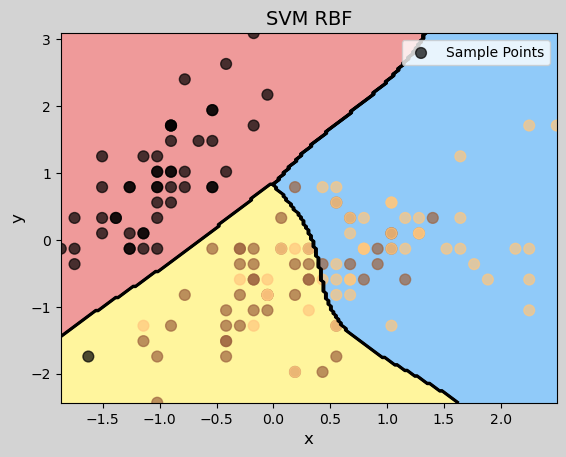

In [10]:
# 绘制网格
xlist1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
xlist2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 200)
XGrid1, XGrid2 = np.meshgrid(xlist1, xlist2)

# 预测并绘制结果
Z = model.predict(np.vstack([XGrid1.ravel(), XGrid2.ravel()]).T)
Z = Z.reshape(XGrid1.shape)

plt.figure('SVM RBF', facecolor='lightgray')
plt.title('SVM RBF', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.tick_params(labelsize=10)

# 绘制超平面
plt.contourf(XGrid1, XGrid2, Z, cmap=ListedColormap(['#EF9A9A', '#FFF59D', '#90CAF9']))
plt.contour(XGrid1, XGrid2, Z, colors=('k',))
plt.scatter(X[:, 0], X[:, 1], s=60, marker='o', alpha=0.7, label='Sample Points', c=y, cmap='copper')
plt.legend()
plt.show()